In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# load data
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

# data cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])

c:\Users\Pc\anaconda3\envs\python_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
df_us = df[df['job_country']=='United States'].copy()
df_us['job_posted_month']=df_us['job_posted_date'].dt.strftime('%B')
df_us_pivot= df_us.pivot_table(
    index='job_posted_month',
    columns='job_title_short',
    aggfunc='size'
)
df_us_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
April,565,40,6049,2801,4867,51,1025,781,991,112
August,903,39,6634,3269,6318,68,1186,903,1515,194
December,648,40,3979,2641,3472,119,601,689,752,212
February,447,24,6124,3060,4956,56,1258,878,1127,90
January,527,36,8494,2655,6915,60,1544,773,1552,114
July,581,39,5201,2570,4876,65,883,747,1095,153
June,446,32,5683,2893,4645,48,1009,812,1033,93
March,438,19,6218,3183,4779,59,1114,829,1150,115
May,279,20,4993,2976,4377,49,839,746,914,90


In [5]:
pd.read_csv('https://lukeb.co/software_csv')

,job_posted_month,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
0,January,13619,9827,5108,4348
1,February,11456,9116,7298,4284
2,March,11102,8178,5814,4159
3,April,14037,9209,7232,4220
4,May,12126,8864,6718,4980
5,June,12003,8065,5902,4781
6,July,11914,8061,6839,4344
7,August,11571,8191,7413,4104
8,September,14016,8447,6139,4094
9,October,11419,8476,5026,4389


In [8]:
# make job posted column the index column and assign a data frame
df_us_software_pivot = pd.read_csv('https://lukeb.co/software_csv' , index_col='job_posted_month') 
df_us_software_pivot

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


### lets merge data frames

In [13]:
df_us_pivot.merge(df_us_software_pivot, on='job_posted_month')

,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,,,,,,,,,,,
April,565,40,6049,2801,4867,51,1025,781,991,112,14037,9209,7232,4220
August,903,39,6634,3269,6318,68,1186,903,1515,194,11571,8191,7413,4104
December,648,40,3979,2641,3472,119,601,689,752,212,14033,9232,6731,4367
February,447,24,6124,3060,4956,56,1258,878,1127,90,11456,9116,7298,4284
January,527,36,8494,2655,6915,60,1544,773,1552,114,13619,9827,5108,4348
July,581,39,5201,2570,4876,65,883,747,1095,153,11914,8061,6839,4344
June,446,32,5683,2893,4645,48,1009,812,1033,93,12003,8065,5902,4781
March,438,19,6218,3183,4779,59,1114,829,1150,115,11102,8178,5814,4159
May,279,20,4993,2976,4377,49,839,746,914,90,12126,8864,6718,4980


In [14]:
df_us_merged= df_us_pivot.merge(df_us_software_pivot, on='job_posted_month')

In [33]:
# return it back to index and make it to be alist

top_5=(df_us_merged
.sum()# Total counts for each job title short
.sort_values(ascending= False)# sort by descending order
.head(5). # five 1st rows
index. # return it back to index
to_list() # make it to be alist
)
top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'Data Analyst',
 'Data Scientist']

### Let's plot 

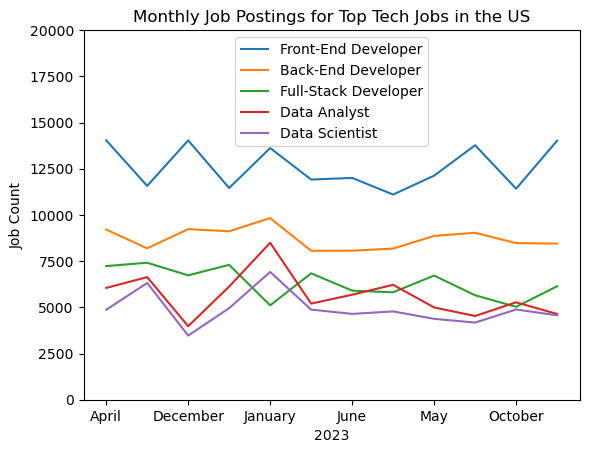

In [35]:
df_us_merged[top_5].plot(kind='line')
plt.title('Monthly Job Postings for Top Tech Jobs in the US')
plt.xlabel('2023')
plt.ylabel('Job Count')
plt.ylim(0, 20000)
plt.legend()
plt.show()